⏳ กำลังโหลดระบบ AI... (Loading Models)
✅ System Ready!

📂 กำลังประมวลผลไฟล์: ./data/label_for_dev108_test_prepared.csv
🤖 กำลังทำนาย 11906 จุดข้อมูล...

📊 CLASSIFICATION REPORT (F1-SCORE)
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98     11084
     Warning       0.62      0.72      0.66       497
    Critical       0.81      0.83      0.82       325

    accuracy                           0.96     11906
   macro avg       0.81      0.84      0.82     11906
weighted avg       0.97      0.96      0.97     11906

🏆 Macro F1-Score: 0.8223


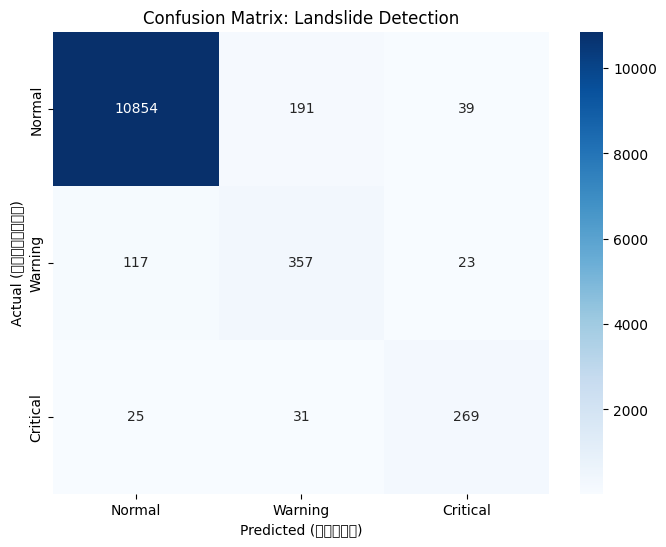

In [1]:
# -*- coding: utf-8 -*-
"""
=========================================================================================
PROJECT: LANDSLIDE EVALUATION (XGBoost + F1 Score Analysis)
ไฟล์: evaluate_xgboost.py
หน้าที่: 
  1. อ่านไฟล์ Test CSV ที่มีเฉลย (Label)
  2. จัดการ Missing Label (Null -> Normal)
  3. รันโมเดลทำนายข้อมูลทั้งไฟล์
  4. วัดผลด้วย Classification Report & Confusion Matrix
=========================================================================================
"""

import pandas as pd
import numpy as np
import joblib
import re
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings

# ปิด Warning
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# =============================================================================
# 1. CONFIGURATION
# =============================================================================
class Config:
    # --- PATHS (แก้ให้ตรงกับไฟล์โมเดล) ---
    XGB_MODEL_PATH = "./model/best_xgboost_model.json"
    SCALER_PATH = "./model/best_xgboost_scaler.save"
    
    # Helper Models
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model2.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler2.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # --- SETTINGS ---
    SEQUENCE_LENGTH = 30
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    
    # Map Text -> Int สำหรับวัดผล
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    # Map Int -> Text สำหรับแสดงผล
    INT_MAP = {0: 'Normal', 1: 'Warning', 2: 'Critical'}

cfg = Config()

# =============================================================================
# 2. EVALUATOR CLASS
# =============================================================================
class LandslideEvaluator:
    def __init__(self):
        print("⏳ กำลังโหลดระบบ AI... (Loading Models)")
        try:
            self.model = XGBClassifier()
            self.model.load_model(cfg.XGB_MODEL_PATH)
            self.scaler = joblib.load(cfg.SCALER_PATH)
            self.iso_model = joblib.load(cfg.ISO_MODEL_PATH)
            self.iso_scaler = joblib.load(cfg.ISO_SCALER_PATH)
            self.lstm_model = load_model(cfg.LSTM_MODEL_PATH, compile=False)
            self.lstm_scaler = joblib.load(cfg.LSTM_SCALER_PATH)
            print("✅ System Ready!")
        except Exception as e:
            print(f"❌ Error loading models: {e}")
            sys.exit(1)

    def _preprocess(self, df):
        """เตรียมข้อมูลและจัดการ Label (Null -> Normal)"""
        df = df.copy()
        # 1. Clean Columns
        df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
        rename_map = {
            'temperature':'temp', 'hum':'humi', 'humidity':'humi',
            'devid': 'devID', 'deviceid': 'devID', 'device': 'devID',
            'time': 'timestamp', 'date': 'timestamp'
        }
        new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
        if new_cols: df = df.rename(columns=new_cols)
        
        # 2. Handle Timestamp
        if 'timestamp' in df.columns:
            df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            df = df.sort_values('timestamp').reset_index(drop=True)
        
        # 3. Ensure Features
        for c in cfg.RAW_COLS:
            if c not in df.columns: df[c] = 0.0
            
        # --- [IMPORTANT] HANDLE LABELS ---
        if cfg.LABEL_COL in df.columns:
            # 4.1 เติม Null ด้วย 'Normal'
            df[cfg.LABEL_COL] = df[cfg.LABEL_COL].fillna('Normal')
            # 4.2 แปลงเป็นตัวเล็ก ตัดช่องว่าง
            df[cfg.LABEL_COL] = df[cfg.LABEL_COL].astype(str).str.lower().str.strip()
            # 4.3 Map เป็นตัวเลข (0, 1, 2)
            df['label_encoded'] = df[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else:
            # ถ้าไม่มีเฉลย ให้สมมติเป็น Normal (0)
            df['label_encoded'] = 0 
            
        return df

    def _generate_features(self, df):
        """สร้างฟีเจอร์ Physics + AI Scores"""
        # Physics
        df['feat_rain_cum_24h'] = df['rain'].rolling(1440, min_periods=1).sum()
        df['feat_soil_rate']    = df['soil'].diff().fillna(0)
        df['feat_geo_abs']      = df['geo'].abs()
        
        # AI: ISO Forest
        try:
            X_iso = self.iso_scaler.transform(df[cfg.RAW_COLS].values)
            df['feat_iso_score'] = self.iso_model.decision_function(X_iso)
        except: df['feat_iso_score'] = 0.0
            
        # AI: LSTM AE
        df['feat_lstm_error'] = 0.0
        try:
            # ต้องทำเป็น Batch เพื่อความเร็ว
            X_lstm = self.lstm_scaler.transform(df[cfg.RAW_COLS].values)
            # Create sequences for whole file
            Xs = []
            # Note: This loop can be slow for very large files, optimization possible
            for i in range(len(df) - cfg.SEQUENCE_LENGTH + 1):
                Xs.append(X_lstm[i : i + cfg.SEQUENCE_LENGTH])
            
            if len(Xs) > 0:
                X_seq = np.array(Xs)
                X_pred = self.lstm_model.predict(X_seq, verbose=0)
                mse = np.mean(np.power(X_seq - X_pred, 2), axis=(1, 2))
                
                # Assign MSE back to DataFrame (align to end of sequence)
                # Index เริ่มต้นที่ SEQUENCE_LENGTH - 1
                df.loc[cfg.SEQUENCE_LENGTH-1:, 'feat_lstm_error'] = mse
        except Exception as e:
            print(f"Warning LSTM: {e}")
            
        return df.fillna(0)

    def _prepare_batch_data(self, df):
        """แปลงข้อมูลทั้งไฟล์เป็น Batch สำหรับวัดผล"""
        # 1. Features Selection
        feature_cols = cfg.RAW_COLS + [c for c in df.columns if c.startswith('feat_')]
        data_matrix = df[feature_cols].values
        labels = df['label_encoded'].values
        
        Xs, ys = [], []
        
        # 2. Sliding Window
        for i in range(len(df) - cfg.SEQUENCE_LENGTH + 1):
            # Window
            window = data_matrix[i : i + cfg.SEQUENCE_LENGTH]
            # Flatten
            Xs.append(window.flatten())
            # Label (ตัวสุดท้ายของ Window)
            ys.append(labels[i + cfg.SEQUENCE_LENGTH - 1])
            
        return np.array(Xs), np.array(ys)

    def evaluate(self, csv_path):
        print(f"\n📂 กำลังประมวลผลไฟล์: {csv_path}")
        if not os.path.exists(csv_path):
            print("❌ ไม่พบไฟล์")
            return

        # 1. Load & Process
        df = pd.read_csv(csv_path)
        df_clean = self._preprocess(df)
        df_feat = self._generate_features(df_clean)
        
        if len(df_feat) < cfg.SEQUENCE_LENGTH:
            print("⚠ ข้อมูลน้อยเกินไปสำหรับทำ Sliding Window")
            return

        # 2. Prepare X, y
        X_test, y_true = self._prepare_batch_data(df_feat)
        
        # 3. Scale
        X_test_scaled = self.scaler.transform(X_test)
        
        # 4. Predict
        print(f"🤖 กำลังทำนาย {len(X_test)} จุดข้อมูล...")
        y_pred_prob = self.model.predict_proba(X_test_scaled)
        y_pred = np.argmax(y_pred_prob, axis=1)
        
        # 5. Report
        self._print_report(y_true, y_pred)

    def _print_report(self, y_true, y_pred):
        # Map 0,1,2 -> Normal, Warning, Critical
        target_names = ['Normal', 'Warning', 'Critical']
        
        # 1. Classification Report
        print("\n" + "="*60)
        print("📊 CLASSIFICATION REPORT (F1-SCORE)")
        print("="*60)
        print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
        
        # 2. Macro F1
        f1 = f1_score(y_true, y_pred, average='macro')
        print(f"🏆 Macro F1-Score: {f1:.4f}")
        print("="*60)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=target_names, 
                    yticklabels=target_names)
        plt.xlabel('Predicted (ทำนาย)')
        plt.ylabel('Actual (ความจริง)')
        plt.title('Confusion Matrix: Landslide Detection')
        plt.show()

# =============================================================================
# 3. RUN EVALUATION
# =============================================================================
if __name__ == "__main__":
    
    # --- 🛠️ ใส่ชื่อไฟล์ Test ที่มี Label ตรงนี้ ---
    TEST_FILE = "./data/label_for_dev108_test_prepared.csv" 
    
    evaluator = LandslideEvaluator()
    evaluator.evaluate(TEST_FILE)